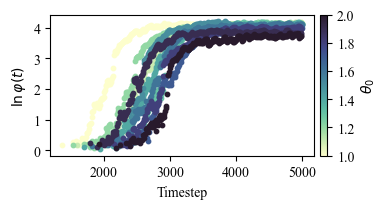

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
import cmocean

folder = "/Users/braydennoh/Research/ChaosRiver/initialchannel"
csv_files = sorted(
    glob.glob(os.path.join(folder, "*.csv")),
    key=lambda f: float(os.path.splitext(os.path.basename(f))[0])
)

# Extract all theta0 values for color mapping
theta0_vals = [float(os.path.splitext(os.path.basename(f))[0]) for f in csv_files]
cmap = cmocean.cm.deep
norm = plt.Normalize(min(theta0_vals), max(theta0_vals))

plt.rcParams["font.family"] = "Times New Roman"
fig, ax = plt.subplots(figsize=(4, 2.2))

for csv_file, theta0 in zip(csv_files, theta0_vals):
    df = pd.read_csv(csv_file)
    col = df.columns[1]
    mask = df[col] >= 0
    timesteps = df['timestep'][mask].to_numpy()
    values = df[col][mask].to_numpy()

    # Bin every 10 timesteps and take average
    if len(timesteps) > 0:
        n_bins = len(timesteps) // 10
        timesteps = timesteps[:n_bins * 10]
        values = values[:n_bins * 10]
        t_binned = timesteps.reshape(-1, 10).mean(axis=1)
        v_binned = values.reshape(-1, 10).mean(axis=1)
        ax.scatter(t_binned, v_binned, s=10, color=cmap(norm(theta0)), label=fr"$\theta_0={theta0:.1f}$")

ax.set_xlabel('Timestep')
ax.set_ylabel(r'$\ln \varphi(t)$')

# Create and add the colorbar
from matplotlib.cm import ScalarMappable
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r"$\theta_0$")

plt.tight_layout()
plt.show()